# NIRISS GR150C Grism Simulation — realistic stpsf PSFs

Same setup as `simulate_niriss.ipynb`, but the sources are point sources rendered
with **realistic NIRISS PSFs from stpsf** (formerly webbpsf) instead of Gaussians.

100 random point sources on the NIRISS detector, each with a spectral shape drawn
from the pystellibs Kurucz library, dispersed through **GR150C** in **F115W, F150W,
F200W**. The PSF is **field-dependent**: each source gets the PSF matched to its
detector position (interpolated from a cached per-filter grid). One PSF per filter
(no wavelength variation along the trace).

> **First run builds the PSF grids** with stpsf (a handful of `calc_psf` calls per
> filter, a few minutes total). They are cached to `~/.cache/grismagic/psf_grids/`,
> so subsequent runs are fast. Outputs go to `output_psf/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from simulate import simulate, build_psf_grid

In [2]:
FILTERS = ('F115W', 'F150W', 'F200W')

results, catalog = simulate(
    n_sources=100,
    seed=47,
    filters=FILTERS,
    orders=('+1',),
    psf=True,           # realistic NIRISS PSF instead of a Gaussian
    psf_num=3,          # 3x3 field grid per filter, interpolated to each source
    psf_fov=25,         # PSF stamp size (detector pixels)
    psf_oversample=4,
    psf_nlambda=3,      # wavelengths averaged for the broadband PSF
    outdir='output_psf',
)

print(f"Simulated {len(catalog)} sources in {len(FILTERS)} filters; outputs in output_psf/")
print('profile:', catalog.meta['profile'], '|', catalog.meta['psf'])

100%|██████████| 1178/1178 [00:03<00:00, 366.37it/s]


Simulated 100 sources in 3 filters; outputs in output_psf/
profile: stpsf_niriss | {'source': 'stpsf.NIRISS DET_DIST', 'field_grid': '3x3 interpolated', 'fov_pixels': 25, 'oversample': 4, 'nlambda': 3}


## The PSF itself

The field grid used for F150W — the PSF at the detector center vs a corner. The
log stretch reveals the diffraction structure (core, rings, NIRISS spikes) that
replaces the featureless Gaussian.

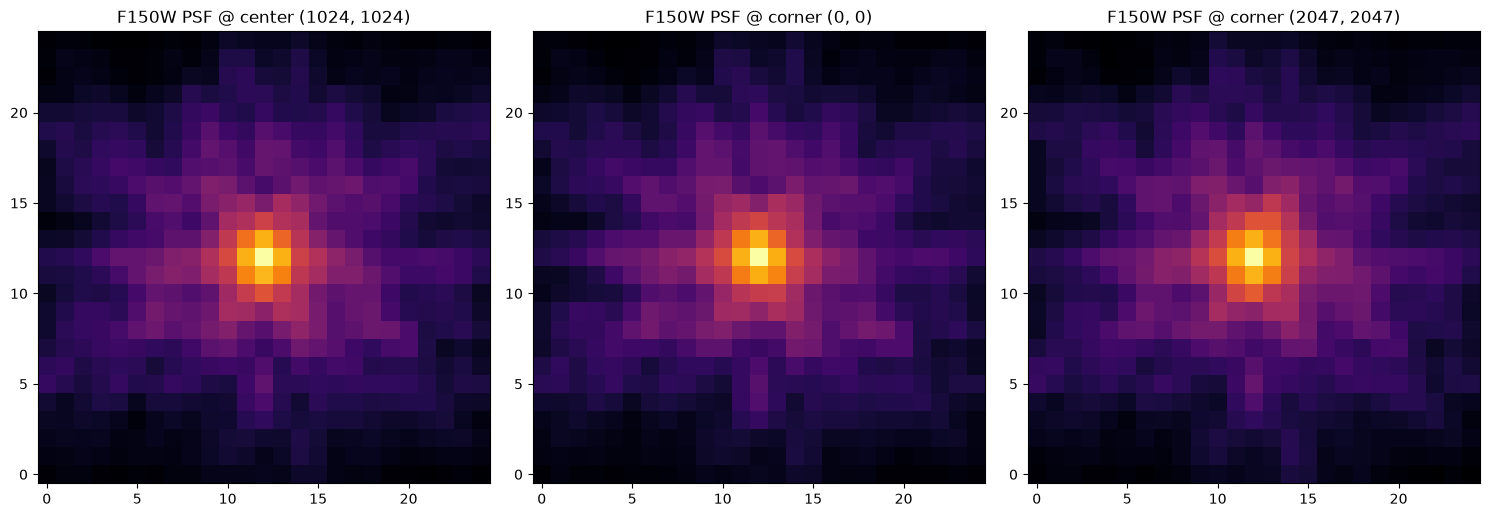

In [5]:
gx, gy, grid = build_psf_grid('F150W', num=3, fov_pixels=25, oversample=4, nlambda=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (iy, ix, lbl) in zip(axes, [(1, 1, 'center (1024, 1024)'),
                                     (0, 0, 'corner (0, 0)'),
                                     (2, 2, 'corner (2047, 2047)')]):
    stamp = grid[iy, ix]
    im = ax.imshow(np.log10(stamp + stamp.max() * 1e-4), origin='lower', cmap='inferno')
    ax.set_title(f'F150W PSF @ {lbl}')
plt.tight_layout()
plt.show()

## Truth catalog

Positions, amplitudes, Kurucz stellar parameters and per-filter fluxes
(`flux_<filt>` = total counts in the direct image = expected counts in the +1 spectrum).

In [6]:
catalog[:10]

id,x,y,amplitude,fwhm_pix,kurucz_index,teff,logg,Z,logz,flux_F115W,flux_F150W,flux_F200W
int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64
0,1470.850086099452,843.0711289779088,0.7174757824803657,1.6,3551,3750.0,3.0,0.06324554979801178,0.5,1.681786624342157e+20,2.1263496593190938e+20,1.5567301320610864e+20
1,1492.7799740370353,831.2921091691904,0.20737175153726772,1.6,1932,10249.999999999996,3.5,0.00019999999494757503,-2.0,3.377343231007393e+19,2.1271897356921577e+19,1.0596745153783749e+19
2,959.6536346480855,1876.5271908454554,0.6949857003100802,1.6,957,32999.99999999997,4.0,0.0006324555142782629,-1.5,9.376071348781472e+19,5.419067247746473e+19,2.441409304176669e+19
3,291.6838547893044,928.206859072772,0.2644687971366461,1.6,1892,15000.000000000004,4.5,6.324555579340085e-05,-2.5,4.004204780737109e+19,2.443370925422656e+19,1.1688631734228146e+19
4,1886.742218477956,1869.4176960841507,0.012512826145289578,1.6,3066,9249.999999999996,4.0,0.00632455525919795,-0.5,2.0875660705136143e+18,1.3394830955168448e+18,6.71858879775593e+17
5,692.7465929849113,1716.689666493792,0.46597908662708154,1.6,2715,5999.999999999997,2.0,0.03169786557555199,0.2,8.906242761658158e+19,7.258532417815508e+19,4.002969940225051e+19
6,470.21270665165173,1077.3788899009753,0.17802211373867324,1.6,642,4999.999999999999,1.0,0.019999999552965164,0.0,3.639021683498592e+19,3.4873720630186107e+19,2.113076233689391e+19
7,1685.1389816288383,1890.9963973603865,0.29772742634032967,1.6,1441,26000.000000000015,3.0,6.324555579340085e-05,-2.5,4.114590679569193e+19,2.41005083640335e+19,1.1010524970330653e+19
8,1048.293975401985,184.42961604881356,0.3650634899743013,1.6,1368,6500.000000000002,0.5,0.0006324555142782629,-1.5,6.827245957201642e+19,5.09550147022834e+19,2.7670364593361388e+19


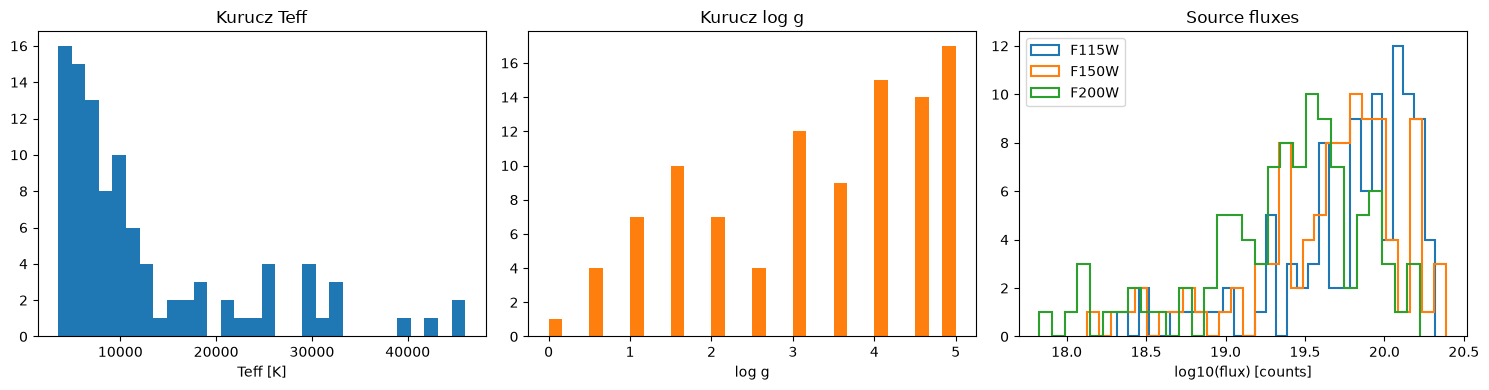

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(catalog['teff'], bins=30, color='C0')
axes[0].set_xlabel('Teff [K]'); axes[0].set_title('Kurucz Teff')
axes[1].hist(catalog['logg'], bins=30, color='C1')
axes[1].set_xlabel('log g'); axes[1].set_title('Kurucz log g')
for filt in FILTERS:
    axes[2].hist(np.log10(catalog[f'flux_{filt}']), bins=30, histtype='step', lw=1.5, label=filt)
axes[2].set_xlabel('log10(flux) [counts]'); axes[2].set_title('Source fluxes'); axes[2].legend()
plt.tight_layout()
plt.show()

## Direct images

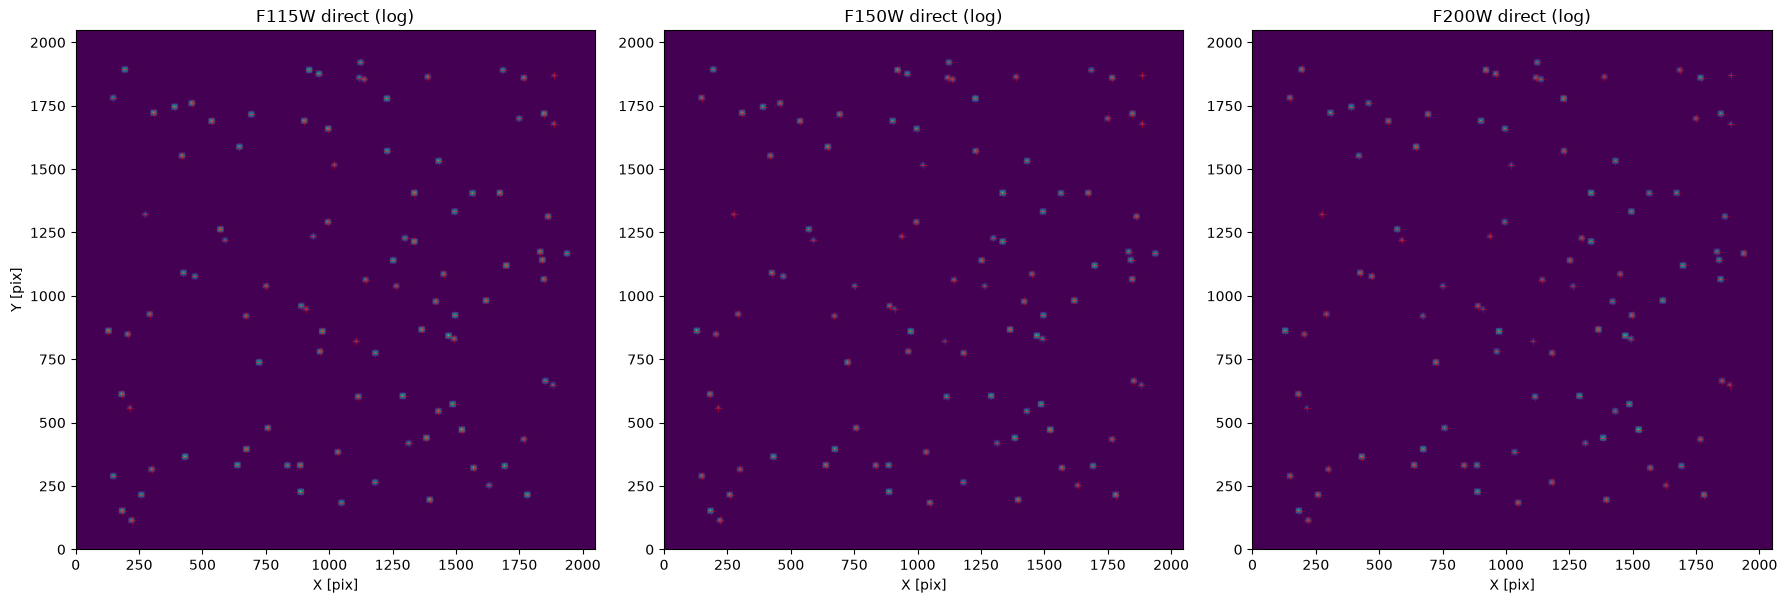

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, filt in zip(axes, FILTERS):
    img = results[filt]['direct']
    ax.imshow(np.log10(img + img.max() * 1e-5), origin='lower', cmap='viridis')
    ax.plot(catalog['x'], catalog['y'], 'r+', ms=6, mew=0.6, alpha=0.5)
    ax.set_title(f'{filt} direct (log)')
    ax.set_xlabel('X [pix]')
axes[0].set_ylabel('Y [pix]')
plt.tight_layout()
plt.show()

## Dispersed (grism) images

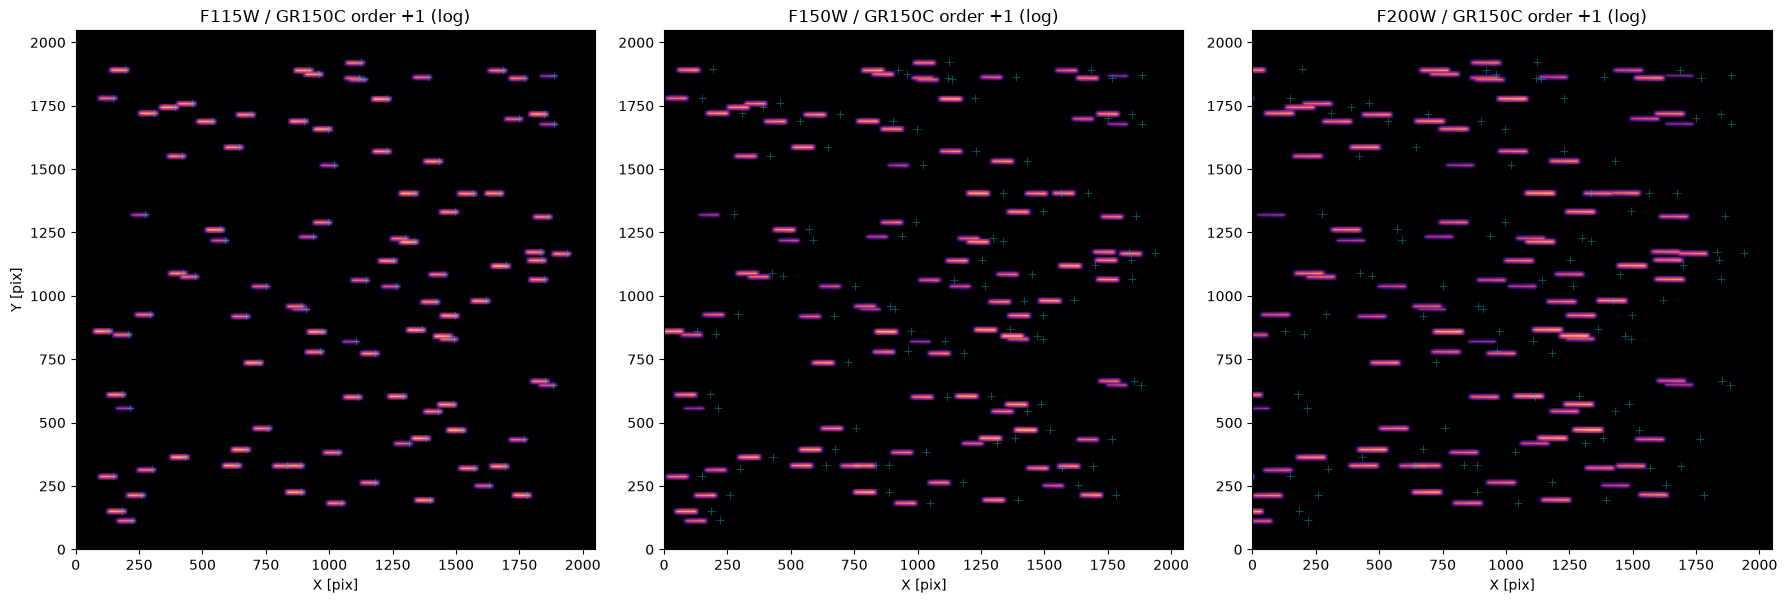

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, filt in zip(axes, FILTERS):
    img = results[filt]['dispersed']
    ax.imshow(np.log10(img + img.max() * 1e-5), origin='lower', cmap='magma')
    ax.plot(catalog['x'], catalog['y'], 'c+', ms=6, mew=0.6, alpha=0.5)
    ax.set_title(f'{filt} / GR150C order +1 (log)')
    ax.set_xlabel('X [pix]')
axes[0].set_ylabel('Y [pix]')
plt.tight_layout()
plt.show()

## Zoom on one source

Direct PSF and its three dispersed traces. GR150C disperses along X; the PSF
structure now shapes both the direct image and the cross-dispersion profile of
the spectral trace.

Source 36: x=1335.5, y=1214.8, Teff=6250 K, logg=2.00, amp=0.90


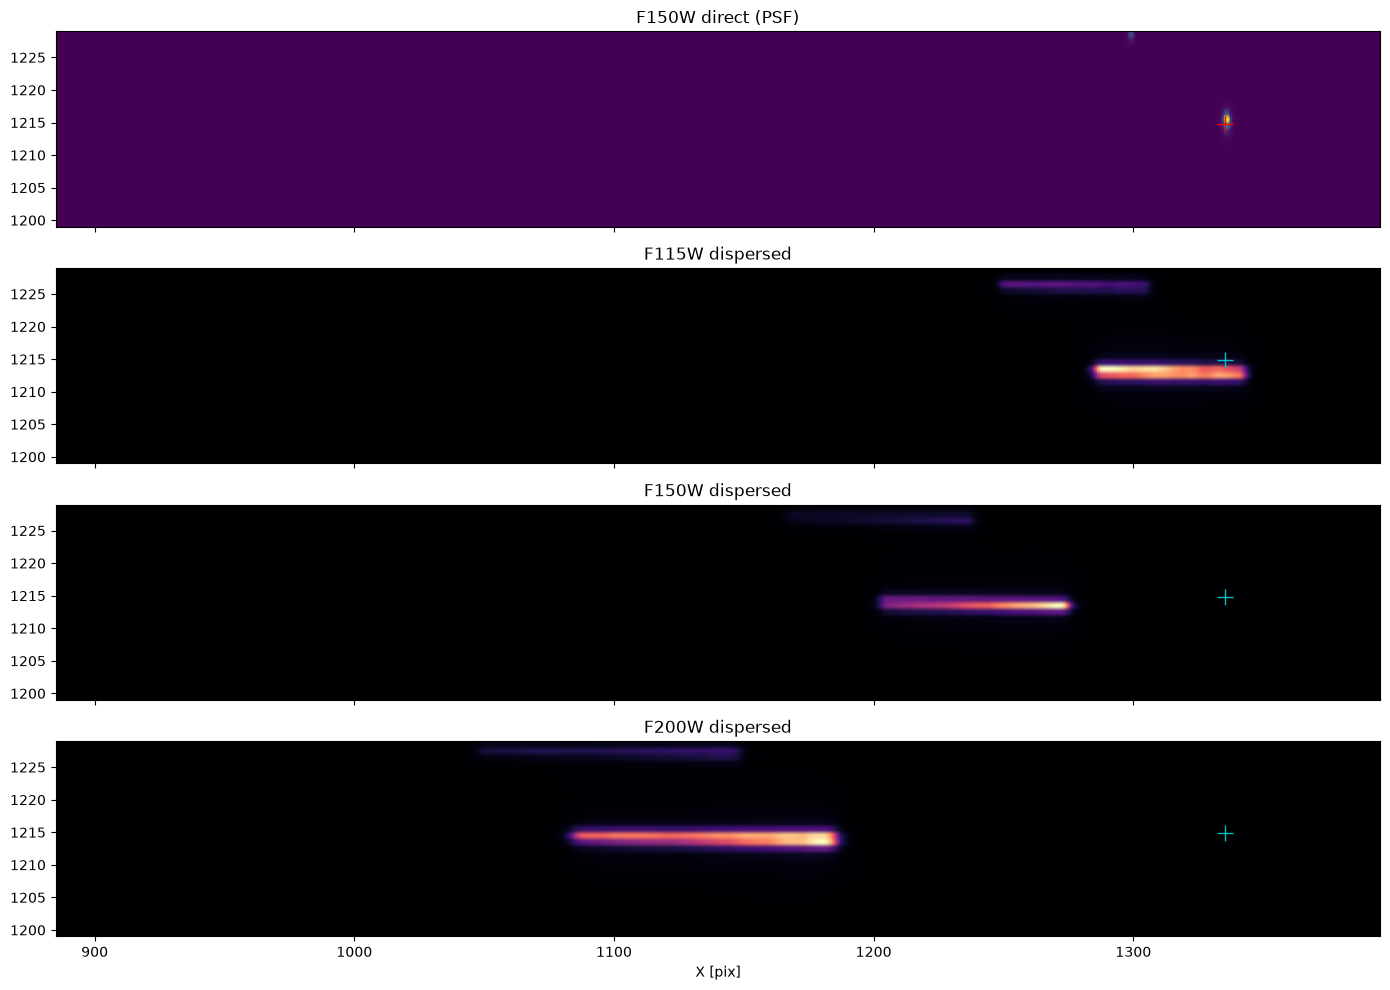

In [10]:
central = (np.abs(catalog['x'] - 1024) < 500) & (np.abs(catalog['y'] - 1024) < 500)
mid = np.argmax(catalog['amplitude'] * central)
xs, ys = catalog['x'][mid], catalog['y'][mid]
xc, yc = int(xs), int(ys)
print(f"Source {catalog['id'][mid]}: x={xs:.1f}, y={ys:.1f}, "
      f"Teff={catalog['teff'][mid]:.0f} K, logg={catalog['logg'][mid]:.2f}, "
      f"amp={catalog['amplitude'][mid]:.2f}")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
dimg = results['F150W']['direct']
axes[0].imshow(dimg[yc-15:yc+15, xc-450:xc+60], origin='lower', cmap='viridis',
               extent=[xc-450, xc+60, yc-15, yc+15], aspect='auto')
axes[0].plot(xs, ys, 'r+', ms=12)
axes[0].set_title('F150W direct (PSF)')
for ax, filt in zip(axes[1:], FILTERS):
    img = results[filt]['dispersed']
    ax.imshow(img[yc-15:yc+15, xc-450:xc+60], origin='lower', cmap='magma',
              extent=[xc-450, xc+60, yc-15, yc+15], aspect='auto')
    ax.plot(xs, ys, 'c+', ms=12)
    ax.set_title(f'{filt} dispersed')
axes[-1].set_xlabel('X [pix]')
plt.tight_layout()
plt.show()

## Flux consistency check

In [11]:
for filt in FILTERS:
    F = np.asarray(catalog[f'flux_{filt}']).sum()
    d = results[filt]['dispersed'].sum()
    dr = results[filt]['direct'].sum()
    print(f"{filt}: dispersed/truth = {d/F:.4f}   direct/truth = {dr/F:.4f}"
          f"   (deficit = flux dispersed off the detector edge)")

F115W: dispersed/truth = 1.0000   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)
F150W: dispersed/truth = 0.9991   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)
F200W: dispersed/truth = 0.9416   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)


## Save results to output/

Writes the three direct and three dispersed images (FITS) plus the truth catalog
(ECSV) to `output/`, using the same filenames and headers as `simulate(write=True)`.

In [12]:
import os
from simulate import write_fits

os.makedirs('output', exist_ok=True)
meta = catalog.meta
for filt in FILTERS:
    cards = {
        'FILTER': filt, 'GRISM': meta['grism'], 'SEED': meta['seed'],
        'NSOURCES': meta['n_sources'], 'PROFILE': meta['profile'],
        'ORDERS': ','.join(meta['orders']),
        'SPECWCS': os.path.basename(meta['specwcs_files'][filt]),
    }
    write_fits(f'output/sim_GR150C_{filt}_direct_psf.fits',
               results[filt]['direct'], {**cards, 'IMTYPE': 'DIRECT'})
    write_fits(f'output/sim_GR150C_{filt}_grism_psf.fits',
               results[filt]['dispersed'], {**cards, 'IMTYPE': 'GRISM'})
catalog.write('output/truth_catalog_psf.ecsv', format='ascii.ecsv', overwrite=True)
print('Saved 3 direct + 3 grism FITS and truth_catalog_psf.ecsv to output/')

Saved 3 direct + 3 grism FITS and truth_catalog_psf.ecsv to output/
